# Quantum science under all three Jalali-lab projects
### from Griffiths' wavefunction to phase retrieval, scattering, and coherent detection -- an OUSD explainer

Three projects in this repo look different -- a dispersion-assisted phase-retrieval
receiver, SEALS light scattering, and a 90-degree optical hybrid -- but **one piece of
quantum mechanics underlies all three**: light is a complex wave $\psi$, and a detector
measures only $|\psi|^2$ (the **Born rule**). Everything follows from "the phase is
hidden":

1. **Phase retrieval** = recovering the hidden phase from $|\psi|^2$ -- the quantum
   measurement problem, solved with dispersive diversity.
2. **SEALS scattering** = a sum over **partial waves**, each carrying angular momentum
   $n\hbar$; the spherical Bessel radial functions are angular-momentum eigenstates.
3. **Optical hybrid** = measuring the complex amplitude by interference, down to the
   **shot-noise** floor $\sqrt N$ -- the photon's particle side.

And one principle threads them: **Fourier / time-bandwidth uncertainty**, the same
$\hbar/2$ Griffiths derives for position-momentum. Uses `dgs/quantum_bridge.py`.

> **Scope (honest).** Maps to OUSD(R&E) technology areas -- *Quantum Science*,
> *Integrated Sensing*, *FutureG* -- as **relevance, not funding or endorsement**.
> Public UCLA/Jalali-lab education (Distribution A); civilian sensing and
> communications. No weapon framing.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import quantum_bridge as qb
print("ready")

ready


## 1. The Born rule -- why phase is hidden (Project 1: phase retrieval)

A detector reports $|\psi|^2$, discarding the phase. So **many fields share one
intensity**: $\sqrt I\,e^{i\phi_a}$ and $\sqrt I\,e^{i\phi_b}$ look identical to the
detector. That ambiguity is exactly what dispersion-assisted Gerchberg-Saxton breaks --
a second, dispersed measurement constrains the phase the first one lost.

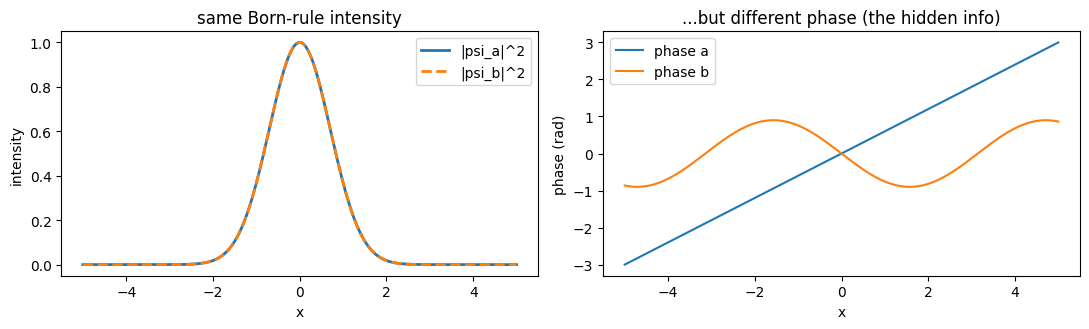

intensities identical: True  fields different: True


In [2]:
x = np.linspace(-5, 5, 400)
I = np.exp(-x**2)                                   # an intensity profile
a, b = qb.phase_ambiguity(I, 0.6*x, -0.9*np.sin(x))  # two DIFFERENT phases, same I
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(x, qb.born_rule(a), lw=2, label="|psi_a|^2")
ax[0].plot(x, qb.born_rule(b), "--", lw=2, label="|psi_b|^2")
ax[0].set(xlabel="x", ylabel="intensity", title="same Born-rule intensity"); ax[0].legend()
ax[1].plot(x, np.angle(a), label="phase a"); ax[1].plot(x, np.angle(b), label="phase b")
ax[1].set(xlabel="x", ylabel="phase (rad)", title="...but different phase (the hidden info)"); ax[1].legend()
plt.tight_layout(); plt.show()
print("intensities identical:", np.allclose(qb.born_rule(a), qb.born_rule(b)),
      " fields different:", not np.allclose(a, b))

## 2. Partial waves carry angular momentum (Project 2: SEALS scattering)

Scattering is a sum over partial waves; the $n$-th carries orbital angular momentum
$n\hbar$ per photon, and its radial function is a **spherical Bessel** function -- an
angular-momentum eigenstate (the matrix-eigenvalue view in `dgs.bessel_linalg`). The
SEALS pattern is a quantum sum over these modes; for a particle of size parameter $x$
the dominant modes cluster near $n\approx x$.

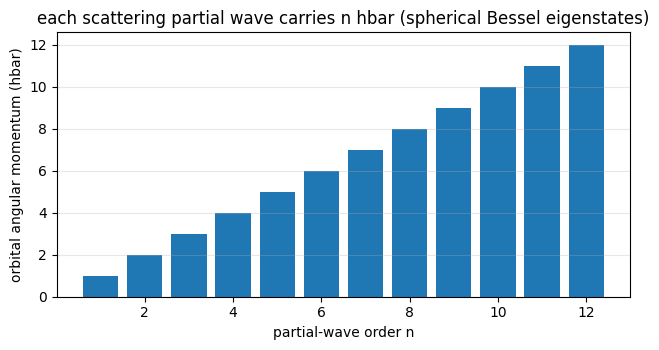

3rd partial wave L = 3.163715451e-34 J s = 3 hbar


In [3]:
n = np.arange(1, 13)
L = qb.partial_wave_angular_momentum(n, hbar=1.0)   # in units of hbar
plt.figure(figsize=(6.5,3.6))
plt.bar(n, L, color="C0")
plt.xlabel("partial-wave order n"); plt.ylabel("orbital angular momentum (hbar)")
plt.title("each scattering partial wave carries n hbar (spherical Bessel eigenstates)")
plt.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()
print("3rd partial wave L =", qb.partial_wave_angular_momentum(3), "J s = 3 hbar")

## 3. Coherent detection vs the shot-noise floor (Project 3: optical hybrid)

The hybrid measures the complex amplitude (I/Q) by interfering with a local oscillator
-- but the photon's particle nature sets a floor: detecting $N$ photons has noise
$\sqrt N$, so $\mathrm{SNR}=\sqrt N$. It improves only as $\sqrt N$, so **4x the light buys
2x the SNR** -- the quantum limit every coherent receiver lives against.

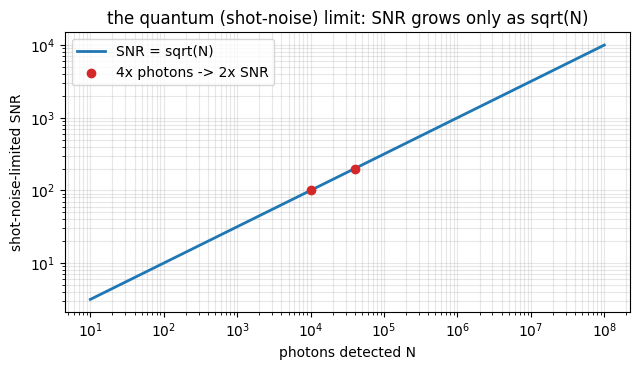

In [4]:
N = np.logspace(1, 8, 100)
plt.figure(figsize=(6.5,3.8))
plt.loglog(N, qb.shot_noise_snr(N), lw=2, label="SNR = sqrt(N)")
plt.scatter([1e4, 4e4], [qb.shot_noise_snr(1e4), qb.shot_noise_snr(4e4)], color="C3", zorder=5,
            label="4x photons -> 2x SNR")
plt.xlabel("photons detected N"); plt.ylabel("shot-noise-limited SNR"); plt.legend()
plt.title("the quantum (shot-noise) limit: SNR grows only as sqrt(N)")
plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 4. The thread -- time-bandwidth uncertainty (all three)

Underneath all three is **Fourier uncertainty**: a pulse and its spectrum cannot both
be narrow, $\Delta t\,\Delta\omega\ge\tfrac12$ -- the same $\hbar/2$ Griffiths derives
for position-momentum. A Gaussian reaches the minimum; a **chirp** (the dispersion the
GS receiver inverts) adds bandwidth and lifts the product. This is why ultrashort
pulses are broadband and why dispersion both blurs and *enables* phase retrieval.

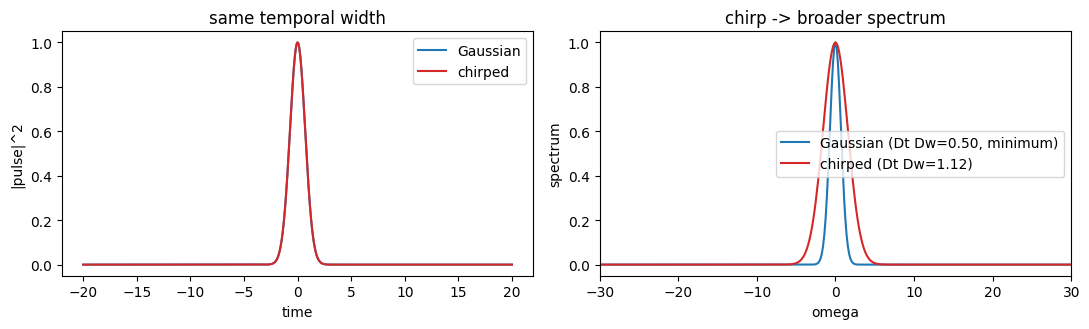

Gaussian Dt*Dw = 0.500 (minimum 1/2); chirped = 1.118


In [5]:
t = np.linspace(-20, 20, 4096)
g = np.exp(-t**2/2); chirp = g*np.exp(1j*1.0*t**2)
tbp_g, tbp_c = qb.time_bandwidth_product(t, g), qb.time_bandwidth_product(t, chirp)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for sig, lbl, c in [(g, f"Gaussian (Dt Dw={tbp_g:.2f}, minimum)", "C0"),
                    (chirp, f"chirped (Dt Dw={tbp_c:.2f})", "C3")]:
    P = np.abs(np.fft.fftshift(np.fft.fft(sig)))**2
    w = np.fft.fftshift(2*np.pi*np.fft.fftfreq(len(t), t[1]-t[0]))
    ax[0].plot(t, np.abs(sig)**2, c, label=lbl.split(" (")[0])
    ax[1].plot(w, P/P.max(), c, label=lbl)
ax[0].set(xlabel="time", ylabel="|pulse|^2", title="same temporal width"); ax[0].legend()
ax[1].set(xlim=(-30,30), xlabel="omega", ylabel="spectrum", title="chirp -> broader spectrum"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Gaussian Dt*Dw = {tbp_g:.3f} (minimum 1/2); chirped = {tbp_c:.3f}")

## What comes after phase retrieval?

Once you have the **full complex field** (amplitude AND phase), everything downstream
opens up: **digitally back-propagate** to undo dispersion or diffraction, do
**holographic imaging** (reconstruct a 3-D scene), **equalize** a fiber channel, or run
**quantum-state tomography**. Phase retrieval is not the end -- it is the step that
turns an intensity measurement back into the field, which is the input to all of it.

## Takeaway

| project | the quantum idea |
|---|---|
| dispersion-GS phase retrieval | Born rule $|\psi|^2$ hides the phase; recover it |
| SEALS scattering | partial waves carry $n\hbar$; spherical-Bessel eigenstates |
| 90-deg optical hybrid | measure the complex amplitude to the shot-noise $\sqrt N$ floor |
| all three | Fourier / time-bandwidth uncertainty, the $\hbar/2$ limit |

One wavefunction, one Born rule, one uncertainty principle -- three projects. From
Griffiths to the receiver. Civilian education; OUSD relevance, not endorsement.